In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
RNG_SEED = 42
np.random.seed(RNG_SEED)

In [4]:
# -----------------------------
# 1) Load dataset
# -----------------------------
train = pd.read_csv("train_clean.csv")
test = pd.read_csv("test_clean.csv")
sample_sub = pd.read_csv("sample_submission.csv")

y = train["TARGET"].values
train_id = train["ID"].values
test_id = test["ID"].values

X_df = train.drop(columns=["ID", "TARGET"])
X_test_df = test.drop(columns=["ID"])

common_cols = [c for c in X_df.columns if c in X_test_df.columns]
X_df = X_df[common_cols]
X_test_df = X_test_df[common_cols]

# Feature engineering: count of zeros per row
X_df["n_zeros"] = (X_df == 0).sum(axis=1)
X_test_df["n_zeros"] = (X_test_df == 0).sum(axis=1)

X = X_df.values
X_test = X_test_df.values

print(f"Train: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Test:  {X_test.shape[0]} rows, {X_test.shape[1]} features")
print(f"Target rate: {y.mean()*100:.2f}%")

Train: 76020 rows, 307 features
Test:  75818 rows, 307 features
Target rate: 3.96%


In [5]:
# -----------------------------
# 2) Grid Search with 5-Fold CV
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)

rf = RandomForestClassifier(random_state=RNG_SEED, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [5, 10, 20],
}

gs = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    refit=True,
    n_jobs=-1,
)
gs.fit(X, y)

best_model = gs.best_estimator_
print(f"[CV] Best params: {gs.best_params_}")
print(f"[CV] Best CV AUC: {gs.best_score_:.5f}")

[CV] Best params: {'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 300}
[CV] Best CV AUC: 0.82113


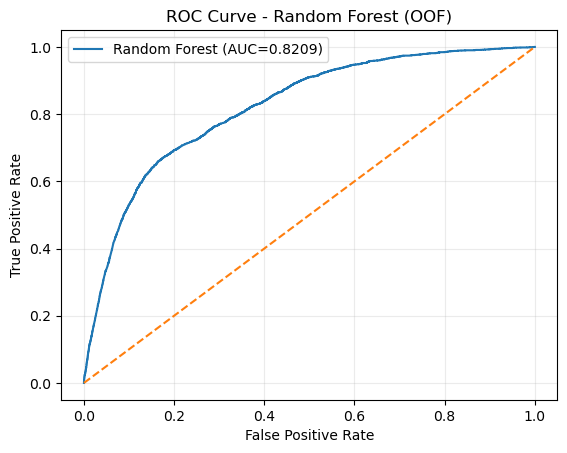

[OOF] AUC: 0.82093


In [6]:
# -----------------------------
# 3) Evaluate: ROC curve (using CV predictions)
# -----------------------------
oof = cross_val_predict(best_model, X, y, cv=cv, method="predict_proba")[:, 1]
overall_auc = roc_auc_score(y, oof)

fpr, tpr, _ = roc_curve(y, oof)
plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC={overall_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (OOF)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print(f"[OOF] AUC: {overall_auc:.5f}")

In [7]:
# -----------------------------
# 4) Generate submission
# -----------------------------
y_test_pred = best_model.predict_proba(X_test)[:, 1]

sub = sample_sub.copy()
sub["TARGET"] = y_test_pred
sub.to_csv("submission_random_forest.csv", index=False)

print("Saved: submission_random_forest.csv")
print(f"Expected Kaggle LB AUC: ~{overall_auc:.4f}")
sub.head()

Saved: submission_random_forest.csv
Expected Kaggle LB AUC: ~0.8209


,ID,TARGET
0,2,0.034950
1,5,0.038644
2,6,0.006341
3,7,0.038929
4,9,0.006687
